<a href="https://colab.research.google.com/github/dgylayse/AkademiQ_DataScience/blob/main/AkademiQ_Data_Science_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DENETİMSİZ ÖĞRENME (UNSUPERVISED LEARNING)

Denetimsiz öğrenme, elimizde etiket (label) olmadan verinin içindeki gizli yapıları keşfetmeye çalışan makine öğrenmesi yaklaşımıdır.

Denetimli öğrenmede: X->Y ilişkisi vardır. Yani doğru cevap bellidir.

Denetimsiz öğrenmede: Sadece X vardır. Model tamamen verinin davranışını anlamaya çalışır.

### Gerçek dünya kullanım alanları:

* Müşteri segmentasyonu
* Sahtekarlık tespiti
* Sensör anomalileri
* Tavsiye sistemleri
* Davranış analizi
* Embedding analizi
* Siber güvenlik

SV. seviyesinde kritik bilgi: gerçek şirketlerde veri çoğu zaman etiketsizdir. Bu yüzden güçlü veri ekipleri önce veriyi anlamaya çalışır sonrası supervised learning'e geçer.

### En yaygın denetimsiz öğrenme problemleri:

1. Clustering (Kümeleme)
2. Dimensionality Reduction (Boyut Azaltma)
3. Anomaly Detection (Anomali Tespiti)

En kritik hata: "Algoritmayı seçip sonra veriye uygulamak"

### Doğru yaklaşım:

1. Veriyi analiz et
2. Veri geometrisini incele
3. Ölçekleri kontrol et
4. Outlier analizi yap
5. Sonra algoritma seç

Çünkü her veri yapısı farklı algoritma ister.

# K-MEANS vs DBSCAN vs PCA

Aşağıdaki tablo gerçek dünyada en sık kullanılan unsupervised learning yaklaşımlarının temel farklarını gösterir.

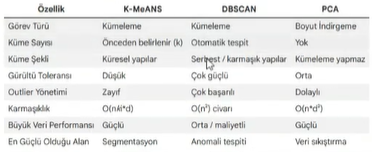

---
## 1. K-MEANS
---
K-means modern veri biliminin en klasik clustering algoritmasıdır.

En güçlü olduğu yer:

* Müşteri segmantasyonu
* davranış gruplama
* recommendation systems
* marketing analizi

Önemli avantajı çok hızlı çalışmasıdır.

Bu yüzden; Google, Amazon, Netflix gibi şirketlerde büyük ölçekli segmentasyon sistemlerinde halen yoğun kullanılır.

Ama kritik zayıflığı:

K-Means: "Her cluster küreseldir." varsayımı yapar.

Yani gerçek dünyadaki karmasşık geometrileri anlamakta zorlanır. Ayrıca outlier'lar merkezi bozabilir.

Bu nedenle production sistemlerinde:

* scaling
* outlier cleaning
* feature engineering

kritik öneme sahiptir.

---
## 2. DBSCAN
---
DBSCAN yoğunluk tabanlı çalışır.

En büyük farkı: Noise ve outlier'ları anlayabilmesidir.

Gerçek dünyada:

* Fraud detection
* Siber saldırı tespiti
* Üretim anomalileri
* IoT sensör analizi

gibi alanlarda çok değerlidir.

Çünkü gerçek veri çoğu zaman temiz değildir.

DBSCAN'in büyük avantajı K sayısını istememesidir.

Yani kaç cluster olduğunu kendi keşfetmeye çalışır.

Ama kritik dezavantajı büyük veri setlerinde maliyetlidir.

Özellikle milyonlarca satırlık sistemlerde hesaplama süresi ciddi artabilir.

Bu nedenle SV seviyesinde veri ekipleri bazen:

* approximate nearest neighbor
* distributed clustering
* GPU acceleration
 kullanır.

 ---
 ## 3. PCA
 ---
PCA bir clustering algoritması değildir. Bu çok kritik bir bilgidir.

PCA: boyut azaltma algoritmasıdır.

Temel amacı: Verideki en yüksek bilgi taşıyan eksenleri bulmaktır.

Modern veri setlerinde 1000+ feature olabilir.

Bu durumda:

* Hesaplama maliyeti artar
* Clustering zorlaşır
* Mesafeler anlamsızlaşır

Bu probleme Curse of Dimensionality denir.

PCA burada veriyi daha düşük boyuta indirir.

Avantajları:

* Hız kazancı
* Gürültü azaltma
* Görselleştirme
* Overfitting azaltımı

Modern AI dünyasında özellikle embedding sistemlerinde çok önemlidir.

Örnek: LLM embedding

Bir embedding 768 veya 1536 boyutlu olabilir. İnsan bunu anlayamaz. Ama PCA/UMAP/t-SNE bunu 2D uzaya indirip görselleştirebilir.




## SV Seviyesinde Kritik Gerçek

Gerçek dünyada bu algoritmalar çoğu zaman tek başına kullanılmaz.

Modern pipeline rnekleri:

* PCA + KMeans Boyutu azalt -> sonra clustering yap
* UMAP + DBSCAN Embedding uzayını sadeleştir -> yoğunluk analizi yap
* AutoEncoder + Clustering Deep Learning ile latent representation çıkar

Yani gerçek mühendislik, algoritmaları kombine edebilme becerisidir.

## Algoritma Seçimi Nasıl Yapılmalı?

K-Means kullan:
* veri büyükse
* cluster yapıları basitse
* hız önemliyse

DBSCAN kullan:
* noise varsa
* outlier önemliyse
* karmaşık geometriler varsa

PCA kullan:
* feature sayısı çok fazlaysa
* görselleştirme gerekiyorsa
* clustering öncesi sadeleştirme isteniyorsa

## Son Kritik Not:

Başlangıç seviyesinde insanlar: "En iyi algoritma hangisi?" sorusunu sorar.

Profesyonel engineerlar ise: "Benim  verim nasıl davranıyor?" sorusunu sorar.

Asıl uzmanlık: algoritma ezberleme değil, verinin geometrisini anlayabilmektir.


In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [4]:
wholesale_customers = fetch_ucirepo(id=292)

X = wholesale_customers.data.features.copy()

print("Dataset Boyutları:", X.shape)

display(X.head())

Dataset Boyutları: (440, 7)


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


In [6]:
print(X.info())

display(X.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB
None


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.44865163  0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873
  -0.06633906]
 [ 1.44865163 -0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684
   0.08915105]
 [ 1.44865163 -0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164
   2.24329255]
 [-0.69029709  0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822
   0.09341105]
 [ 1.44865163  0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782
   1.29934689]]


#Elbow Method

In [11]:
from sklearn import cluster
inertia_values = []

cluster_range = range(1,11)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)


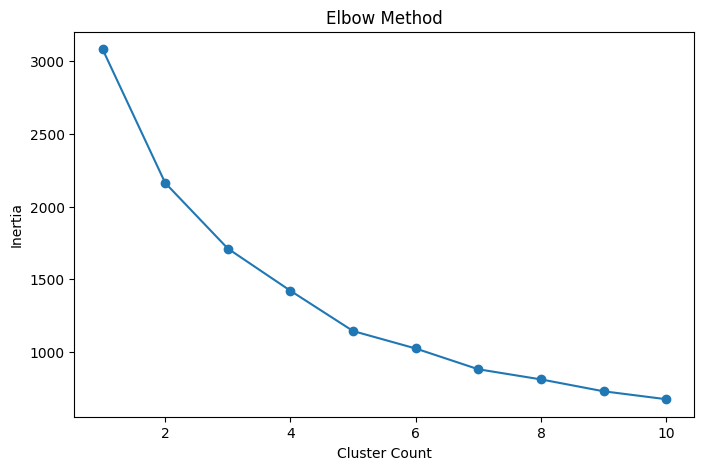

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    inertia_values,
    marker='o',
)

plt.xlabel('Cluster Count')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()


In [14]:
kmeans_pipeline = Pipeline(steps=[
    (
        "kmeans",
        KMeans(
            n_clusters=4,
            random_state=42,
            n_init=10
        )
    )
])

kmeans_pipeline.fit(X_scaled)

Pipeline(steps=[('kmeans', KMeans(n_clusters=4, n_init=10, random_state=42))])

In [15]:
clusters = kmeans_pipeline.predict(X_scaled)

X_clustered = X.copy()

X_clustered['Cluster'] = clusters

display(X_clustered.head())

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,12669,9656,7561,214,2674,1338,0
1,2,7057,9810,9568,1762,3293,1776,0
2,2,6353,8808,7684,2405,3516,7844,0
3,1,13265,1196,4221,6404,507,1788,1
4,2,22615,5410,7198,3915,1777,5185,0


In [16]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:",round(score,4))

Silhouette Score: 0.4425


## Score:

* 0.70+ ise çok güçlü ayrışma
* 0.50 - 0.70 ise güçlü
* 0.25 - 0.50 ise orta/kabul edilebilir ayrışma
* < 0.25 ise zayıf ayrışma